In [4]:
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import(classification_report, confusion_matrix, roc_auc_score, roc_curve)
tf.random.set_seed(42)
np.random.seed(42)

In [5]:
df_train = pd.read_csv("Heart_Disease_train.csv")
df_val = pd.read_csv("Heart_Disease_val.csv")
df_test = pd.read_csv("Heart_Disease_test.csv")

X_train = df_train.drop(columns=['Heart_Disease']).values.astype(np.float32)
y_train = df_train['Heart_Disease'].values.astype(np.float32)

X_val = df_val.drop(columns=['Heart_Disease']).values.astype(np.float32)
y_val = df_val['Heart_Disease'].values.astype(np.float32)


X_test = df_test.drop(columns=['Heart_Disease']).values.astype(np.float32)
y_test = df_test['Heart_Disease'].values.astype(np.float32)

print(f"Train: {X_train.shape}")
print(f" val: {X_val.shape}")
print(f" Test: {X_test.shape}")

print(f" number of features: {X_train.shape[1]}")

Train: (35020, 20)
 val: (7480, 20)
 Test: (7500, 20)
 number of features: 20


In [7]:
with open("Heart_Disease_metadata.json") as f:
    metadata = json.load(f)
feature_cols = metadata['feature']
train_medians = metadata['train_medians']
scaler_mean = np.array(metadata['scaler_mean'], dtype = np.float32)
scaler_Scale = np.array(metadata['scaler_scale'], dtype=np.float32)

print(f"Loaded metadata  for {len(feature_cols)} features")
scaler_Scale

Loaded metadata  for 20 features


array([14.434363  ,  0.49999264, 20.232439  , 14.408184  ,  6.3700795 ,
        0.79906285,  0.66628003,  0.6999886 ,  0.69726366,  0.74875826,
        0.45809537,  0.39937758,  0.43461636,  0.49023885,  0.29843262,
       23.124372  , 17.25946   , 14.498148  , 31.65949   , 43.23937   ],
      dtype=float32)

In [8]:
def build_ann(n_features):
    inputs = keras.Input(shape=(n_features,), name="feature")

    X= keras.layers.Dense(128, kernel_regularizer = keras.regularizers.l2(1e-4))(inputs)
    X= keras.layers.BatchNormalization()(X)
    X= keras.layers.Activation("relu")(X)
    X= keras.layers.Dropout(0.3)(X)


    X= keras.layers.Dense(64, kernel_regularizer = keras.regularizers.l2(1e-4))(X)
    X= keras.layers.BatchNormalization()(X)
    X= keras.layers.Activation("relu")(X)
    X= keras.layers.Dropout(0.3)(X)

    X= keras.layers.Dense(32)(X)
    X= keras.layers.Activation("relu")(X)
    X= keras.layers.Dropout(0.2)(X)

    outputs = keras.layers.Dense(1, activation='sigmoid', name='prob')(X)
    return keras.Model(inputs, outputs, name="HeartDiseaseANN")

In [9]:
model = build_ann(X_train.shape[1])
model.summary()

Model: "HeartDiseaseANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ feature (InputLayer)                 │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │           2,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ prob (Dense)                         │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,825 (54.00 KB)

 Trainable params: 13,441 (52.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss = 'binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

In [11]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=25,
        
        restore_best_weights=True, mode='max', verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=10,
        min_lr=1e-6, mode='max', verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        "Heart_Disease.keras", monitor="val_loss",
        save_best_only = True, mode='max', verbose=0
    ),
]
history = model.fit(
    X_train, y_train,
    epochs = 300, batch_size=32,
    validation_data=(X_val, y_val),
    callbacks = callbacks, verbose=1,
)
print(f"\nEpochs run: {len(history.history['loss'])}")
print(f"best val AUC: {max(history.history['val_loss']):.4f}")

Epoch 1/300
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8543 - auc: 0.9373 - loss: 0.3286 - precision: 0.8449 - recall: 0.8397 - val_accuracy: 0.9305 - val_auc: 0.9859 - val_loss: 0.1689 - val_precision: 0.9206 - val_recall: 0.9302 - learning_rate: 5.0000e-04
Epoch 2/300
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9083 - auc: 0.9712 - loss: 0.2281 - precision: 0.8988 - recall: 0.9039 - val_accuracy: 0.9362 - val_auc: 0.9881 - val_loss: 0.1558 - val_precision: 0.9313 - val_recall: 0.9311 - learning_rate: 5.0000e-04
Epoch 3/300
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9166 - auc: 0.9750 - loss: 0.2130 - precision: 0.9091 - recall: 0.9111 - val_accuracy: 0.9406 - val_auc: 0.9895 - val_loss: 0.1476 - val_precision: 0.9320 - val_recall: 0.9406 - learning_rate: 5.0000e-04
Epoch 4/300
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9214 - auc: 0.9778 - loss: 0.2010 - precision: 0.9138 - recall: 0.9168 - val_accuracy: 0.9472 - val_auc: 0.9912 

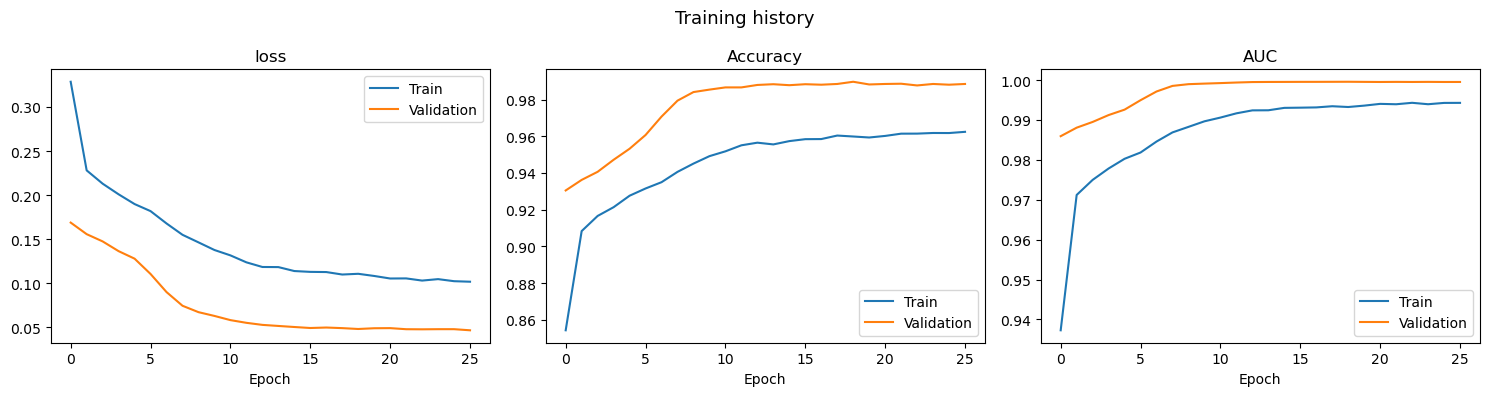

In [14]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history.history["loss"], label='Train')
axes[0].plot(history.history["val_loss"], label='Validation')
axes[0].set_title("loss")
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history["accuracy"], label='Train')
axes[1].plot(history.history["val_accuracy"], label='Validation')
axes[1].set_title("Accuracy")
axes[1].set_xlabel('Epoch')
axes[1].legend()

# axes[2].scatter(y_test, y_pred, alpha=0.3, s=5, color="steelblue")
axes[2].plot(history.history['auc'],  label='Train')
axes[2].plot(history.history['val_auc'],  label='Validation')
axes[2].set_xlabel('Epoch')
axes[2].set_title('AUC')
axes[2].legend()

plt.suptitle('Training history', fontsize=13)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
model.load_weights('Heart_Disease.keras')
test_results = model.evaluate(X_test, y_test, verbose=0)
for name, value in zip(model.metrics_names, test_results):
    print(f"{name:<12}: {value:.4f}")

loss        : 0.1835
compile_metrics: 0.9255


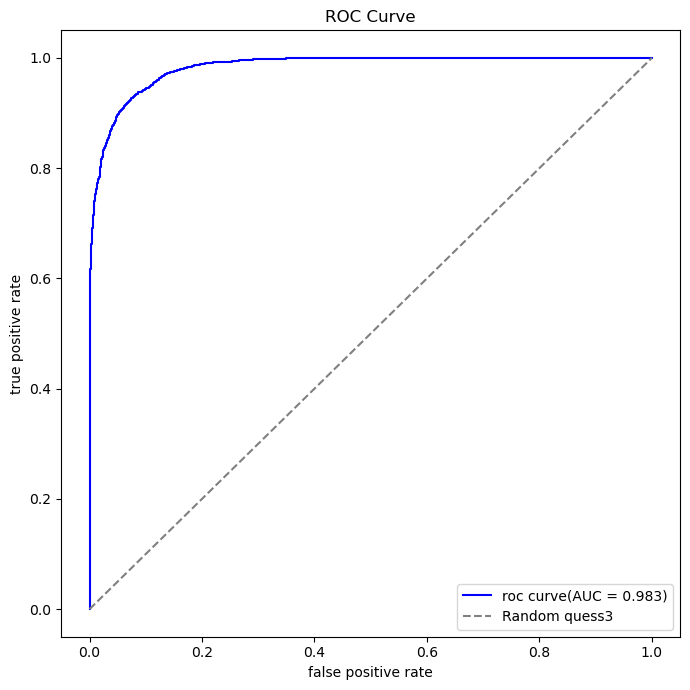

ROC-AUC: 0.9828


In [20]:
prob = model.predict(X_test, verbose = 0).flatten()
auc_score = roc_auc_score(y_test,prob)

fpr, tpr, thresholds = roc_curve(y_test,prob)

plt.figure(figsize = (7, 7))
plt.plot(fpr, tpr, color='blue', label=f'roc curve(AUC = {auc_score:.3f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--', label="Random quess3")
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()

print(f'ROC-AUC: {auc_score:.4f}')

                  precision    recall  f1-score   support

No Heart_Disease       0.93      0.93      0.93      4024
   Heart_Disease       0.92      0.92      0.92      3476

        accuracy                           0.93      7500
       macro avg       0.92      0.93      0.93      7500
    weighted avg       0.93      0.93      0.93      7500



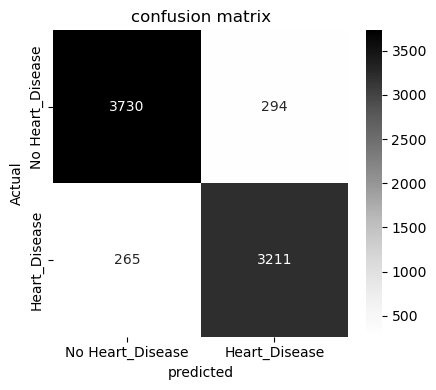

In [31]:
y_pred = (prob >= 0.5).astype(int)
from sklearn.preprocessing import StandardScaler
import seaborn as sns

print(classification_report(y_test, y_pred, target_names=['No Heart_Disease', 'Heart_Disease']))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Grays',
           xticklabels=['No Heart_Disease', 'Heart_Disease'],
           yticklabels=['No Heart_Disease', 'Heart_Disease'])
plt.ylabel('Actual')
plt.xlabel('predicted')
plt.title("confusion matrix")
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches = 'tight')
plt.show()

In [37]:
model.save('Heart_Disease.keras')
with open('Heart_Disease_kit.pkl', 'wb') as f:
    pickle.dump({
        'scaler_mean': scaler_mean,
        'scaler_scale': scaler_Scale,
        'feature_cols': feature_cols,
        'train_medians': train_medians,
    }, f)
print('Heart_Disease_ANN.keras')
print('saved_Heart_Disease_kit.pkl')

Heart_Disease_ANN.keras
saved_Heart_Disease_kit.pkl
